<p align="center">
  <br/>
    <a href="https://pdf-redaction.com/" target="_blank"><img alt="PDF Redaction"
    src="https://pdf-redaction.com/images/pdf-redaction-logo.svg" width="450" style="max-width: 100%;"></a>
  <br/>
</p>

<p align="center">
    <i>Secure Your PDFs with AI-powered Redaction</i>
</p>

<p align="center">
    <a target="_blank" href="https://colab.research.google.com/github/StabRise/pdf-redaction-api/blob/main/jupyter/PDF-Redaction-API.ipynb">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://github.com/stabrise/spark-pdf/blob/main/LICENSE"><img alt="GitHub" src="https://img.shields.io/github/license/stabrise/spark-pdf.svg?color=blue"></a>
    <a href="https://stabrise.com"><img alt="StabRise" src="https://img.shields.io/badge/powered%20by-StabRise-orange.svg?style=flat&colorA=E1523D&colorB=blue"/>
    </a>
</p>

# Example of using PDF Redaction API

**Source**: [https://github.com/StabRise/pdf-redaction-api](https://github.com/StabRise/pdf-redaction-api)

[Swagger API documentation](https://api.pdf-redaction.com/api/docs)

Documentation: [https://pdf-redaction.com/docs/api/](https://pdf-redaction.com/docs/api/)

Self-Hosted PDF Redaction API:[https://pdf-redaction.com/docs/api-self-hosted/](https://pdf-redaction.com/docs/api-self-hosted/)

Web UI: [https://pdf-redaction.com](https://pdf-redaction.com)

For generate API Key please go to the: [https://pdf-redaction.com/apikeys/](https://pdf-redaction.com/apikeys/)

For check usage: [https://pdf-redaction.com/apikeys/usage/](https://pdf-redaction.com/apikeys/usage/)

Put API Key to the env variable `PDF_REDACTION_API_KEY` or to `.env` file.

## Limitations for free version
* 10 page per request
* 100 Free requests per month
* 5 requests per minute


## Installing dependencies for displaying PDF files

In [8]:
%%bash
if [[ "$OSTYPE" == "linux-gnu"* ]]; then
    echo "Detected Linux. Installing poppler-utils..."
    apt-get install -y poppler-utils wget
elif [[ "$OSTYPE" == "darwin"* ]]; then
    echo "Detected macOS. Installing poppler..."
    brew install poppler wget
else
    echo "Unsupported OS: $OSTYPE"
fi

Detected macOS. Installing poppler...


✔︎ JSON API cask.jws.json
✔︎ JSON API formula.jws.json
To reinstall 26.03.0, run:
  brew reinstall poppler
To reinstall 1.25.0, run:
  brew reinstall wget


In [6]:
%pip install requests pdf2image pillow python-dotenv


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Downloading example PDF files

In [6]:
!wget https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/sample_document_en.pdf

--2026-03-22 14:08:50--  https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/sample_document_en.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1112179 (1.1M) [application/octet-stream]
Saving to: ‘sample_document_en.pdf’

sample_document_en. 100%[===================>]   1.06M  --.-KB/s    in 0.1s    

2026-03-22 14:08:50 (9.09 MB/s) - ‘sample_document_en.pdf’ saved [1112179/1112179]



# Display original PDF

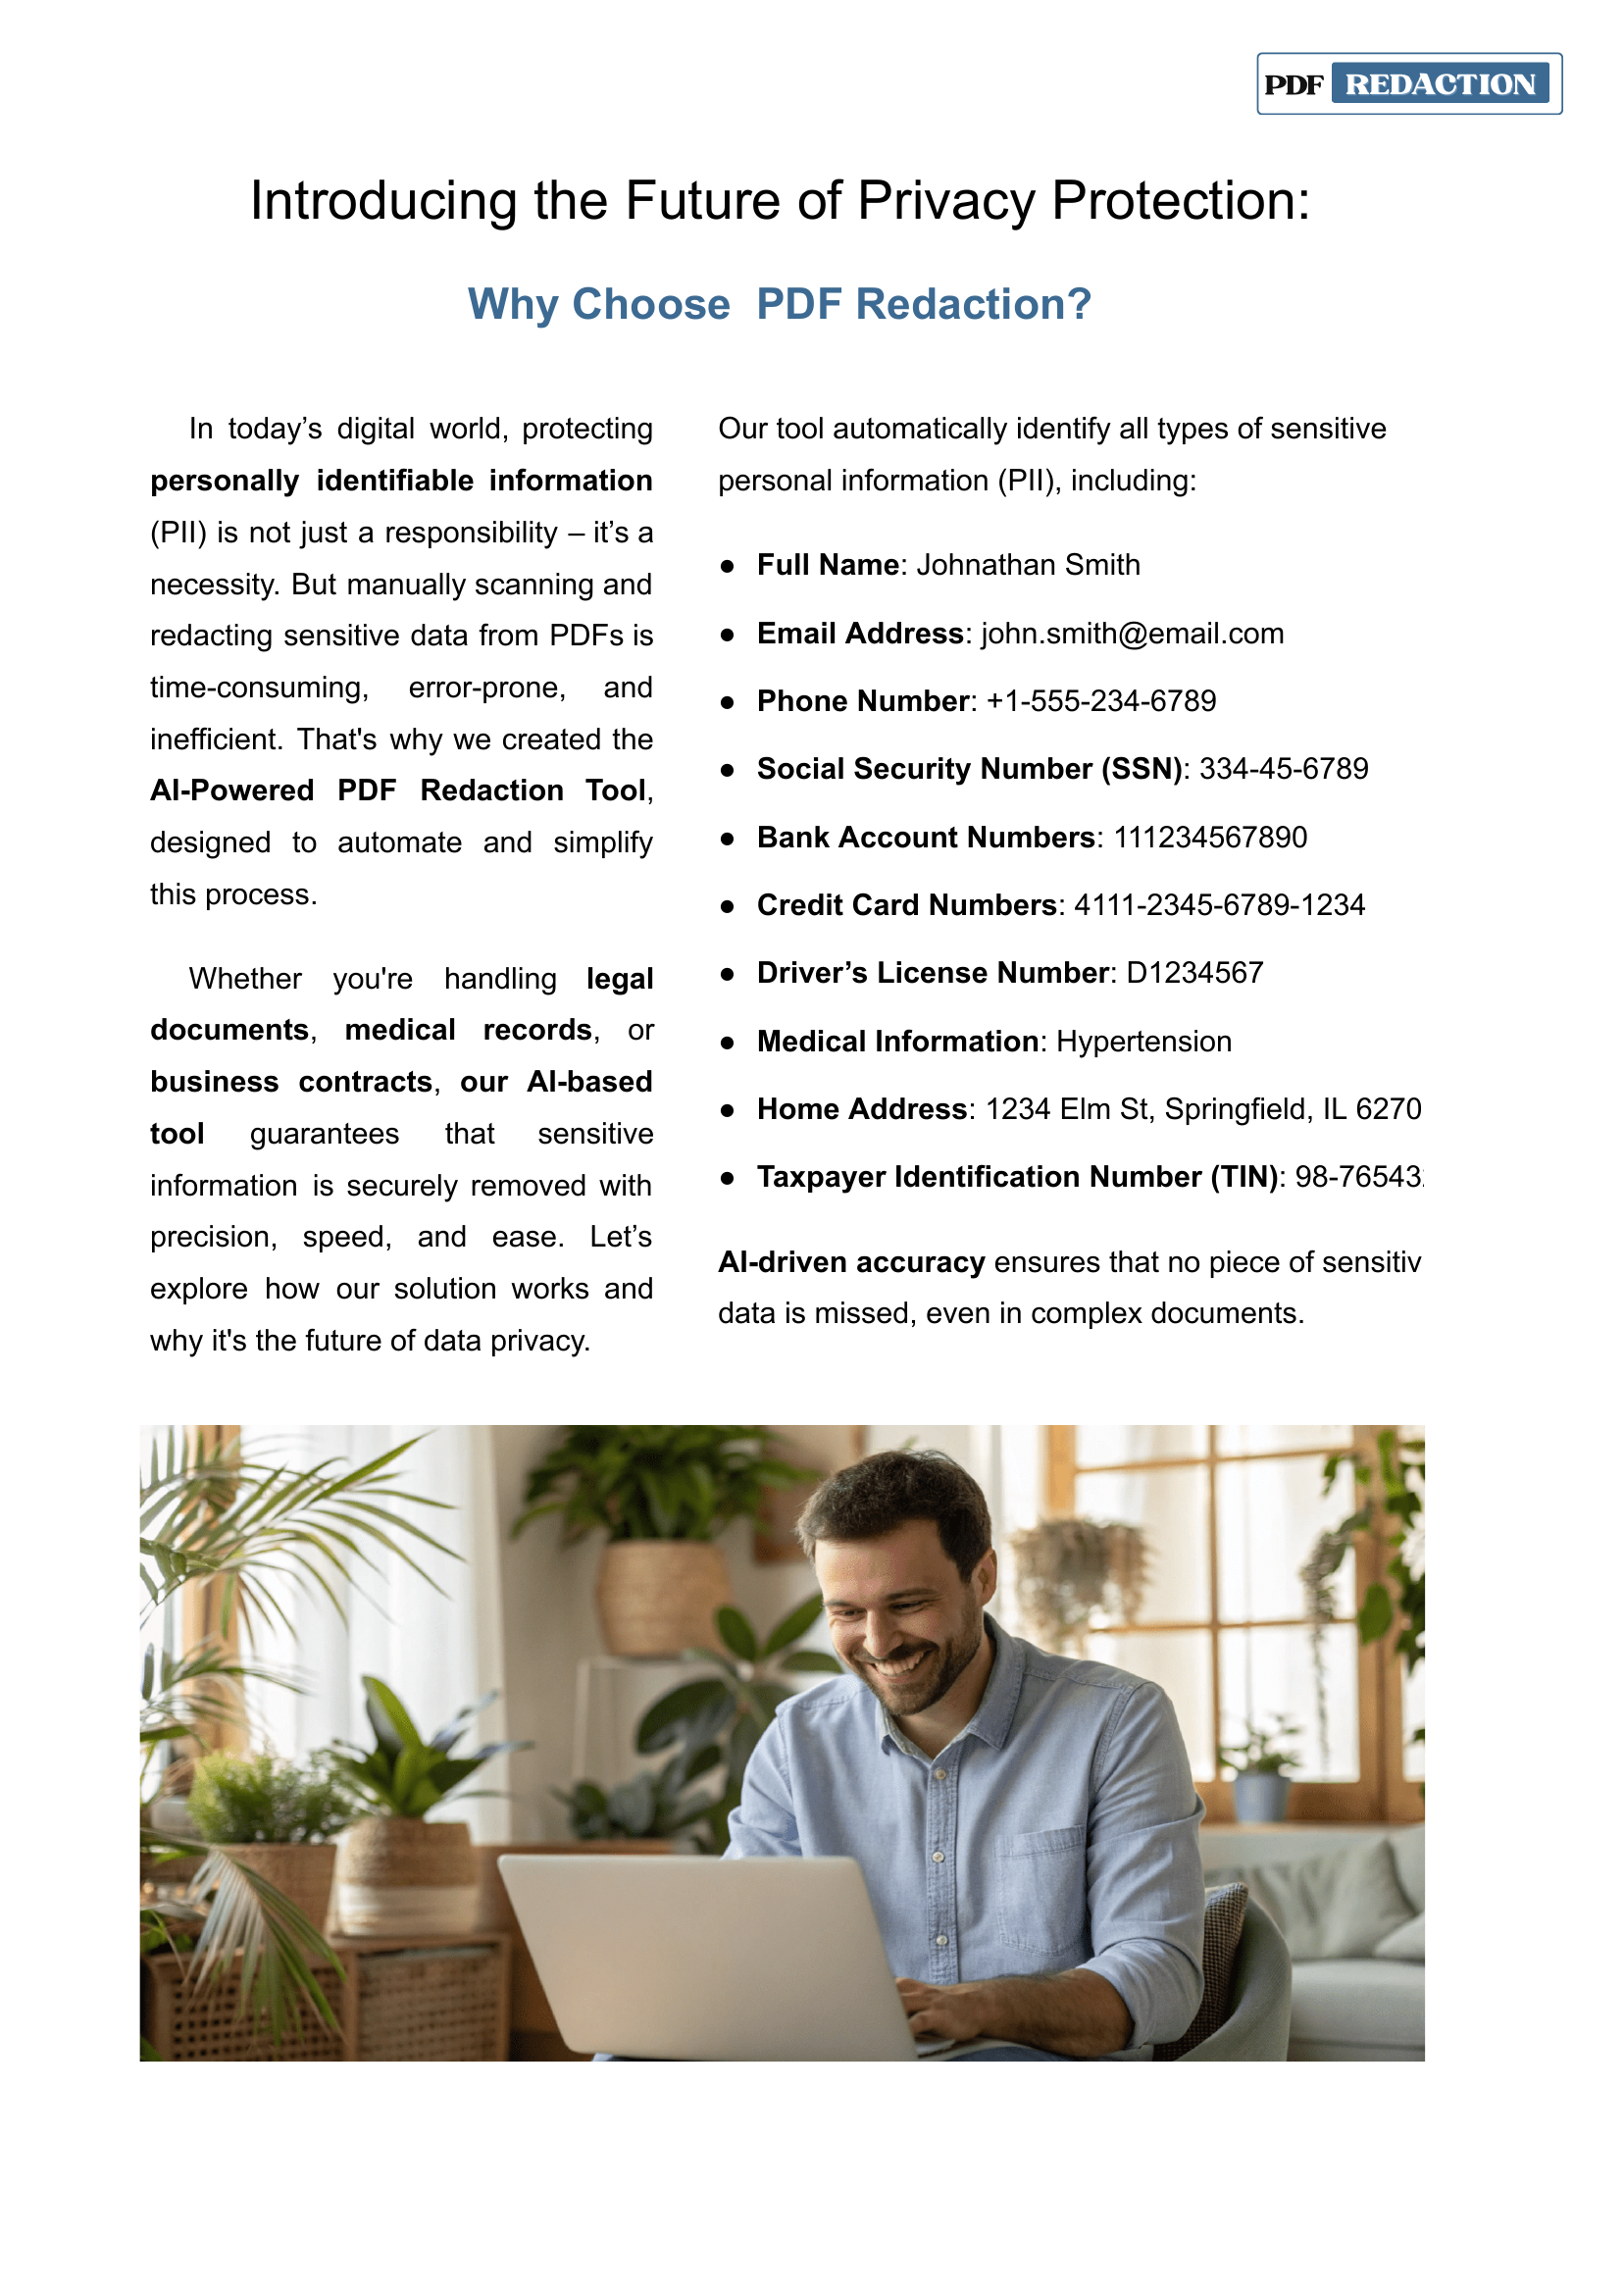

In [1]:
from pdf2image import convert_from_path
from IPython.display import display

# File path to your PDF (replace with your actual file path)
file_path = "./sample_document_en.pdf"
# or use local file from example folder
#file_path = "../examples/pdfs/sample_document_en.pdf"

def display_pdf(pdf_path):
    """Display first page of the pdf file"""
    # Convert first page of PDF to image
    pages = convert_from_path(pdf_path, first_page=1, last_page=1)  # returns a list of PIL Images

    # Display first page
    display(pages[0])

display_pdf(file_path)

# Redact PDF using API

In [ ]:
import requests
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()

pdf_redaction_api_base_url = os.environ.get(
    "PDF_REDACTION_API_BASE_URL",
    "https://api.pdf-redaction.com/api")

pdf_redaction_api_key = os.environ.get("PDF_REDACTION_API_KEY")

# Assemble full URL
pdf_redaction_api_url = f"{pdf_redaction_api_base_url}/anonymize/file/pdf"

# Create output directory path
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist

# Compute output file name based on input file name
input_file = Path(file_path)
output_file_path = output_dir / f"redacted_{input_file.name}"

headers = {
    #"accept": "application/pdf",
    "X-API-Key": pdf_redaction_api_key,
}

# Read the PDF file and send it to the API
with open(file_path, "rb") as f:
    files = {
        "pdf": ("sample_document.pdf", f, "application/pdf")
    }
    payload = {
        "force_ocr": "false",
        "rotated_text": "false",
        "redact_text": "true",
        "min_chunk_size": 0,
    }
    response = requests.post(pdf_redaction_api_url, headers=headers, data=payload, files=files)

print("Status code:", response.status_code)

# Save the redacted PDF to a file
if response.status_code == 200:
    with open(output_file_path, "wb") as out:
        out.write(response.content)
    print(f"Redacted PDF saved as '{output_file_path}'.")
else:
    print("Error:")#, response.text)

## Display redacted PDF

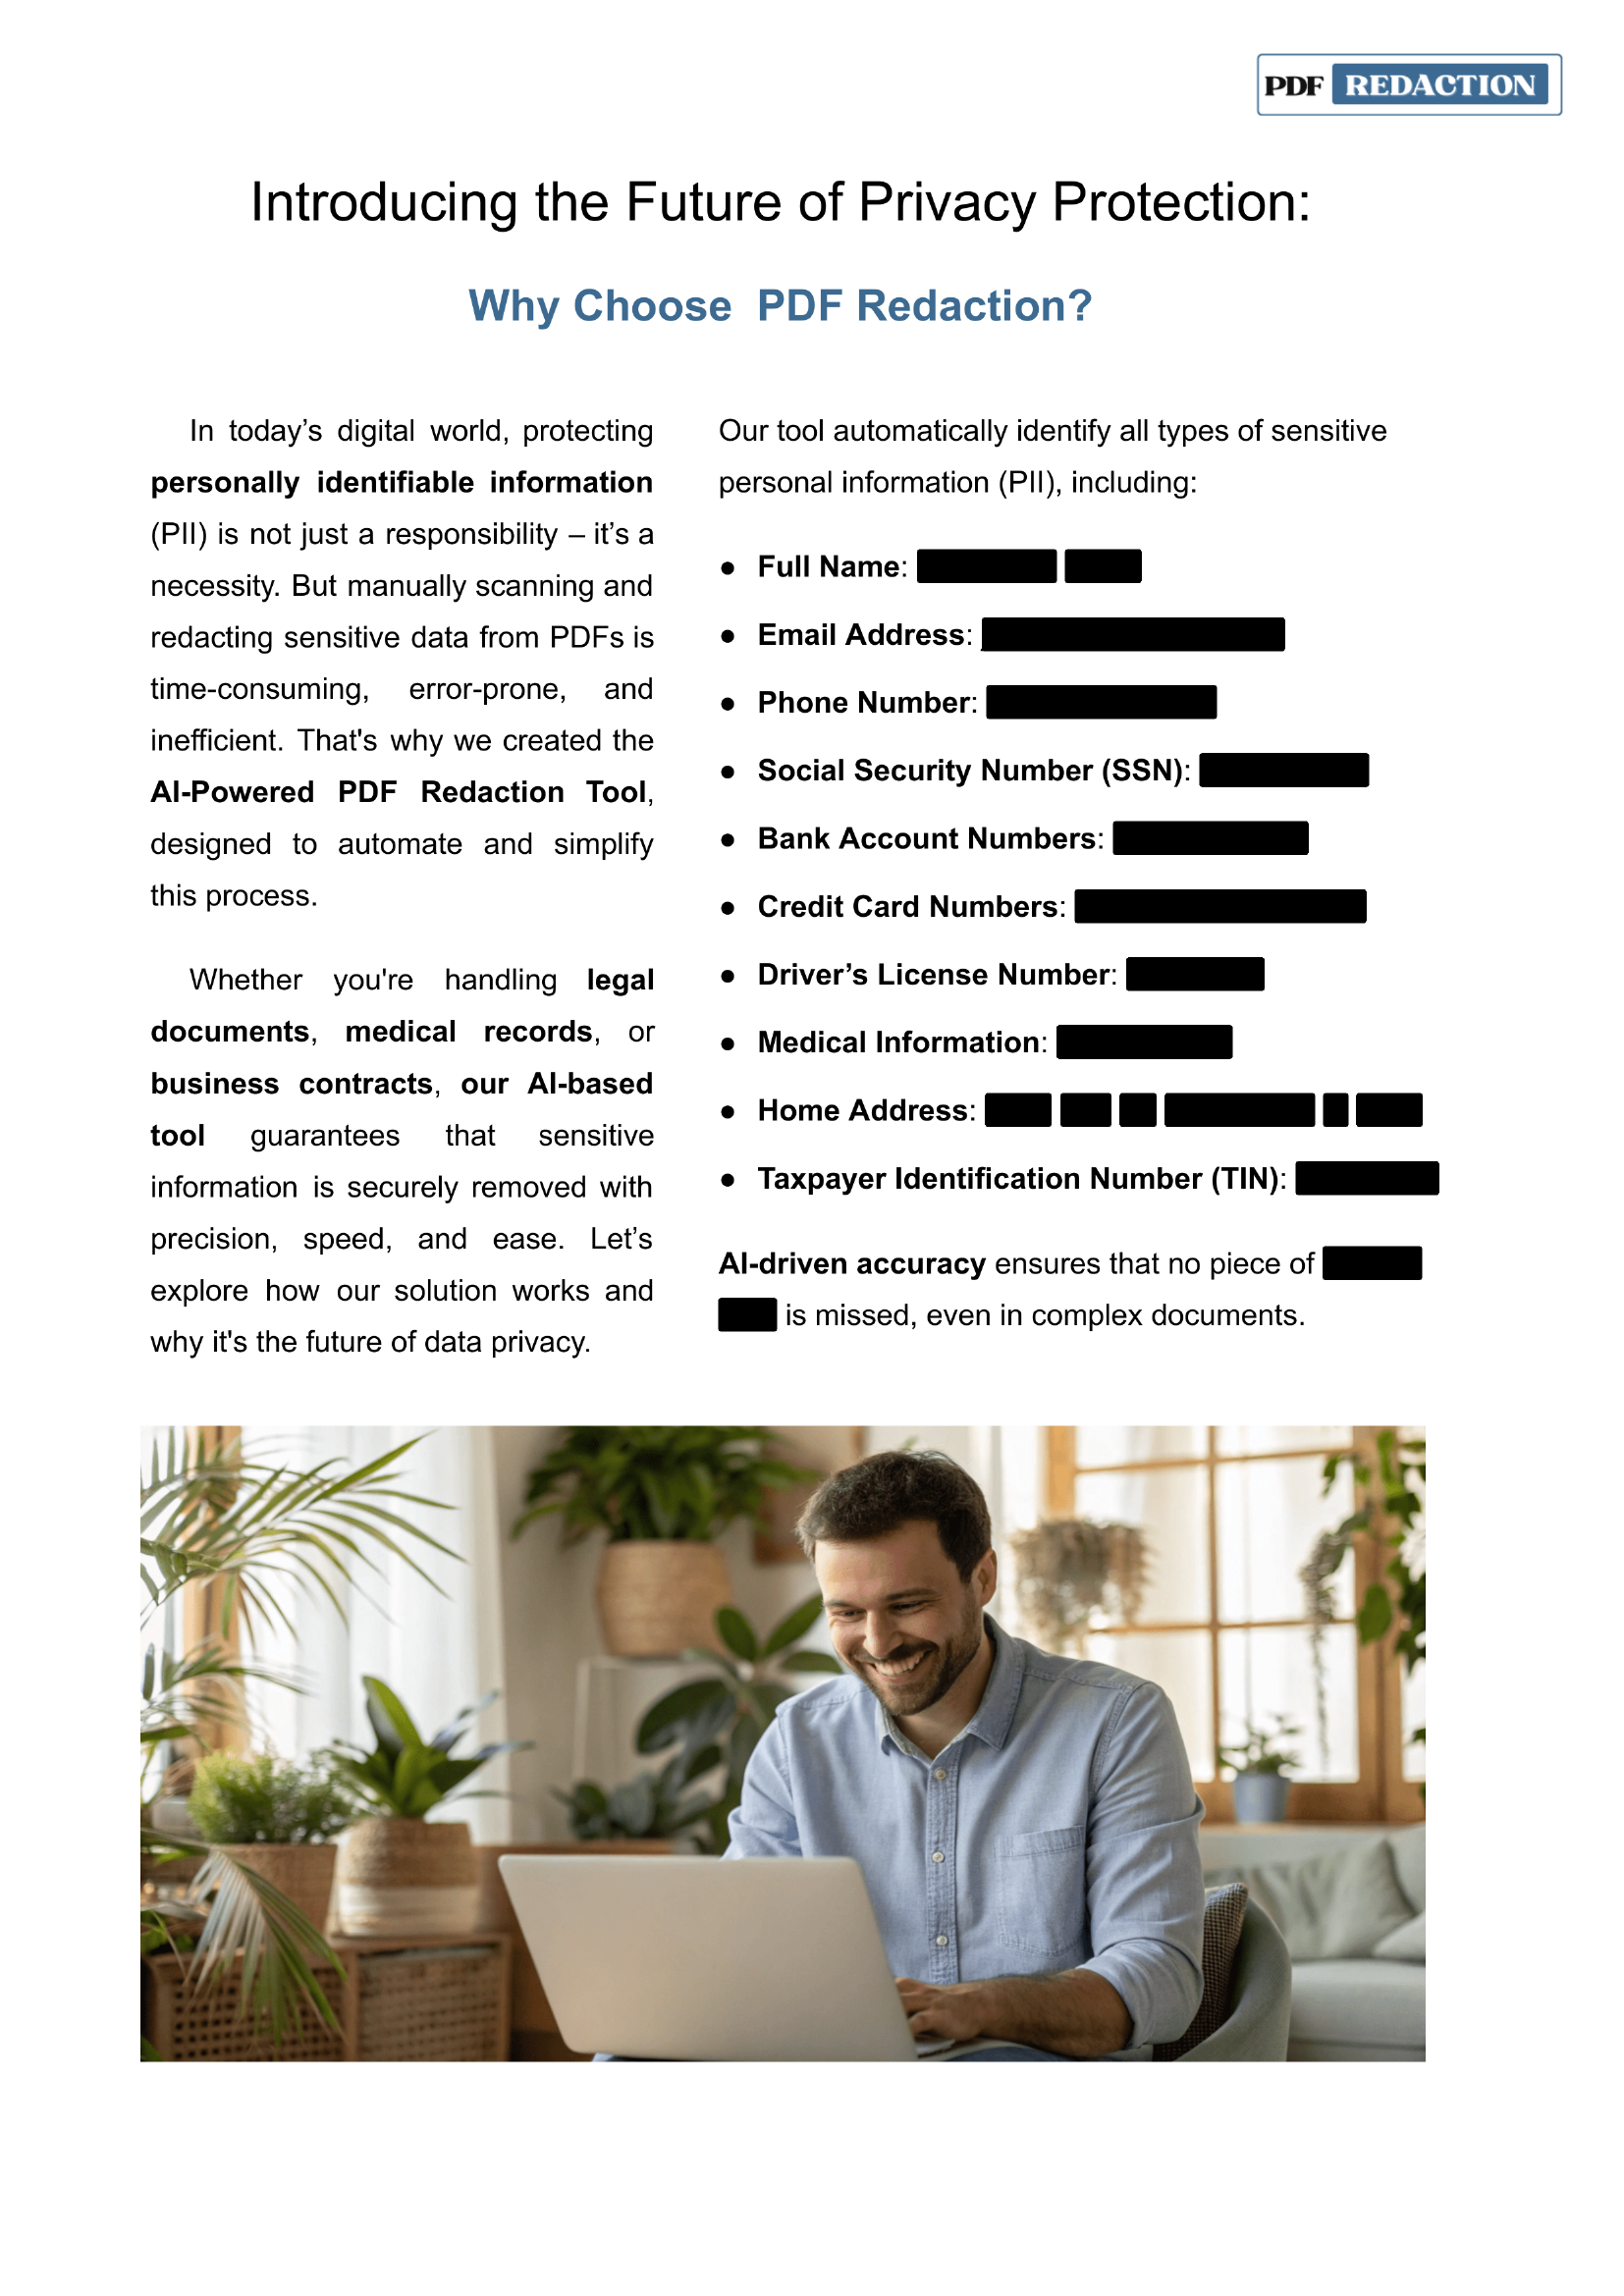

In [7]:
display_pdf(output_file_path)